In [36]:
import pandas as pd

df = pd.read_csv("../data/digit-recognizer/train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(33600, 784) (8400, 784)


In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

print(X_train.shape, X_test.shape)

(33600, 2) (8400, 2)


In [40]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression


lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
accuracy_score(y_test, y_pred_lr)

0.34095238095238095

/home/tesserxt/AllProjects/jupyter/jupyter_venv/lib/python3.13/site-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


<Axes: >

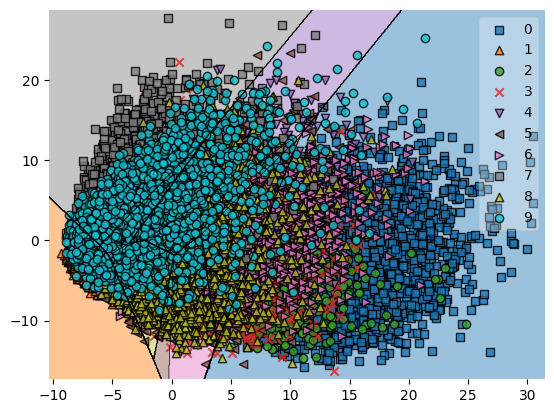

In [43]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_train, y_train.values, clf=lr)

In [22]:
X_test.shape

(8400, 200)

In [29]:
import numpy as np

#np.float64(0.961688866710621)
np.sort(lr.predict_proba(X_test)[0])

array([5.83309560e-07, 1.74699526e-06, 7.38735144e-05, 8.68079071e-05,
       5.63869565e-04, 8.41920880e-04, 1.89093959e-03, 3.14346789e-03,
       3.17079236e-02, 9.61688867e-01])